In [ ]:
# pure_sha3.py

# Round constants for the Iota step ( random 16 bit hex values (64 bit in total) )
RC = [0x0000000000000001, 0x0000000000008082, 0x800000000000808A,
      0x8000000080008000, 0x000000000000808B, 0x0000000080000001,
      0x8000000080008081, 0x8000000000008009, 0x000000000000008A,
      0x0000000000000088, 0x0000000080008009, 0x000000008000000A,
      0x000000008000808B, 0x800000000000008B, 0x8000000000008089,
      0x8000000000008003, 0x8000000000008002, 0x8000000000000080,
      0x000000000000800A, 0x800000008000000A, 0x8000000080008081,
      0x8000000000008080, 0x0000000080000001, 0x8000000080008008]

# Rotation constants for the Rho step
ROT = [[0, 36, 3, 41, 18],
       [1, 44, 10, 45, 2],
       [62, 6, 43, 15, 61],
       [28, 55, 25, 21, 56],
       [27, 20, 39, 8, 14]]

def rotl64(a, n):
    """Helper function to rotate a 64-bit integer left by n bits."""
    return ((a << n) | (a >> (64 - n))) & 0xFFFFFFFFFFFFFFFF

def theta(state):
    C = [state[x][0] ^ state[x][1] ^ state[x][2] ^ state[x][3] ^ state[x][4] for x in range(5)]
    D = [C[(x - 1) % 5] ^ rotl64(C[(x + 1) % 5], 1) for x in range(5)]
    for x in range(5):
        for y in range(5):
            state[x][y] ^= D[x]
    return state

def rho_and_pi(state):
    B = [[0 for _ in range(5)] for _ in range(5)]
    for x in range(5):
        for y in range(5):
            # Pi rearranges the lanes, Rho applies the rotation
            B[y][(2 * x + 3 * y) % 5] = rotl64(state[x][y], ROT[x][y])
    return B

def chi(state):
    # We need a temporary copy so we don't overwrite data we still need to read
    temp = [[state[x][y] for y in range(5)] for x in range(5)]
    for x in range(5):
        for y in range(5):
            state[x][y] = temp[x][y] ^ ((~temp[(x + 1) % 5][y]) & temp[(x + 2) % 5][y])
    return state

def iota(state, round_index):
    state[0][0] ^= RC[round_index]
    return state

def keccak_f1600(state):
    """Runs the 24 scrambling rounds on the 1600-bit state."""
    for i in range(24):
        state = theta(stateß)
        state = rho_and_pi(state)
        state = chi(state)
        state = iota(state, i)
    return state

def simulate_heavy_workload(num_blocks=500):
    """Simulates hashing a large file block by block."""
    # Initialize a state matrix of 5x5 containing 64-bit integers
    state = [[0 for _ in range(5)] for _ in range(5)]
    
    print(f"Running Keccak-f[1600] permutation for {num_blocks} blocks...")
    for _ in range(num_blocks):
        state = keccak_f1600(state)
    print("Done!")

if __name__ == "__main__":
    simulate_heavy_workload()

Running Keccak-f[1600] permutation for 500 blocks...
Done!


Profiling CPU execution time up to 1000 blocks (stepping by 40)...
Crunching complete! Generating plot...


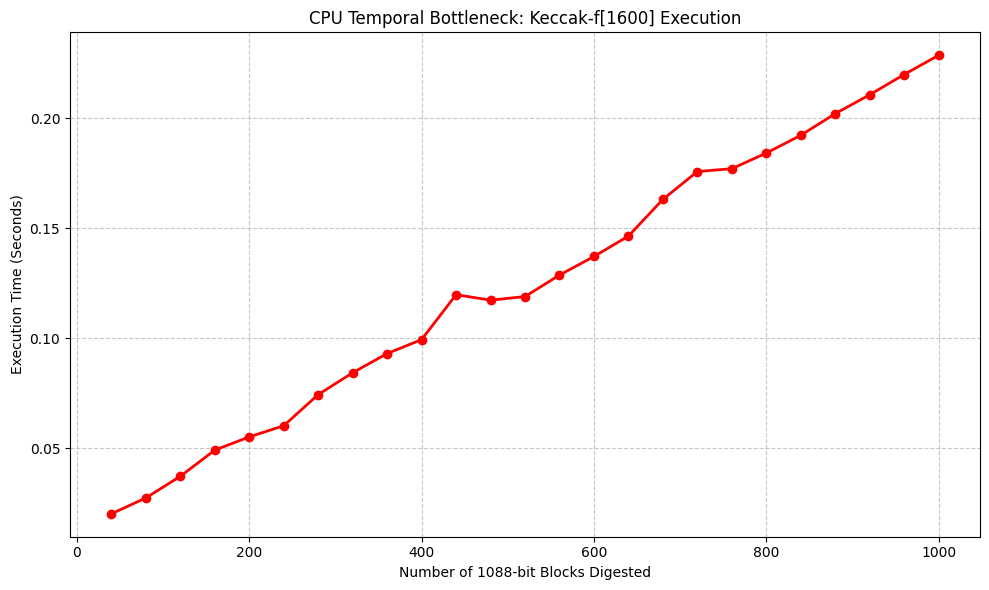

In [14]:
def profile_and_plot(max_blocks=1000, step=40):
    """Times the permutation execution from 40 to max_blocks and plots the result."""
    block_counts = []
    execution_times = []
    
    print(f"Profiling CPU execution time up to {max_blocks} blocks (stepping by {step})...")
    
    # Adding a 'step' parameter to the range function
    for n in range(step, max_blocks + 1, step):
        # Reset the tensor to zero for a clean test
        state = [[0 for _ in range(5)] for _ in range(5)]
        
        # Start the clock
        start_time = time.time()
        
        # Digest 'n' blocks sequentially
        for _ in range(n):
            state = keccak_f1600(state)
            
        # Stop the clock
        end_time = time.time()
        
        # Record the data
        block_counts.append(n)
        execution_times.append(end_time - start_time)

    print("Crunching complete! Generating plot...")

    # Generate the graph
    plt.figure(figsize=(10, 6))
    # Using markers ('o') so you can clearly see the 40-block jumps
    plt.plot(block_counts, execution_times, color='red', marker='o', linewidth=2)
    plt.title('CPU Temporal Bottleneck: Keccak-f[1600] Execution')
    plt.xlabel('Number of 1088-bit Blocks Digested')
    plt.ylabel('Execution Time (Seconds)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Now it will fly through this and plot data points every 40 blocks
    profile_and_plot(max_blocks=1000, step=40)

Profiling 1000 blocks across Keccak state sizes...
b = 25   (w=1 ) | Rounds: 12 | Time: 0.0924s
b = 50   (w=2 ) | Rounds: 14 | Time: 0.0986s
b = 100  (w=4 ) | Rounds: 16 | Time: 0.1162s
b = 200  (w=8 ) | Rounds: 18 | Time: 0.1291s
b = 400  (w=16) | Rounds: 20 | Time: 0.1598s
b = 800  (w=32) | Rounds: 22 | Time: 0.2165s
b = 1600 (w=64) | Rounds: 24 | Time: 0.2229s


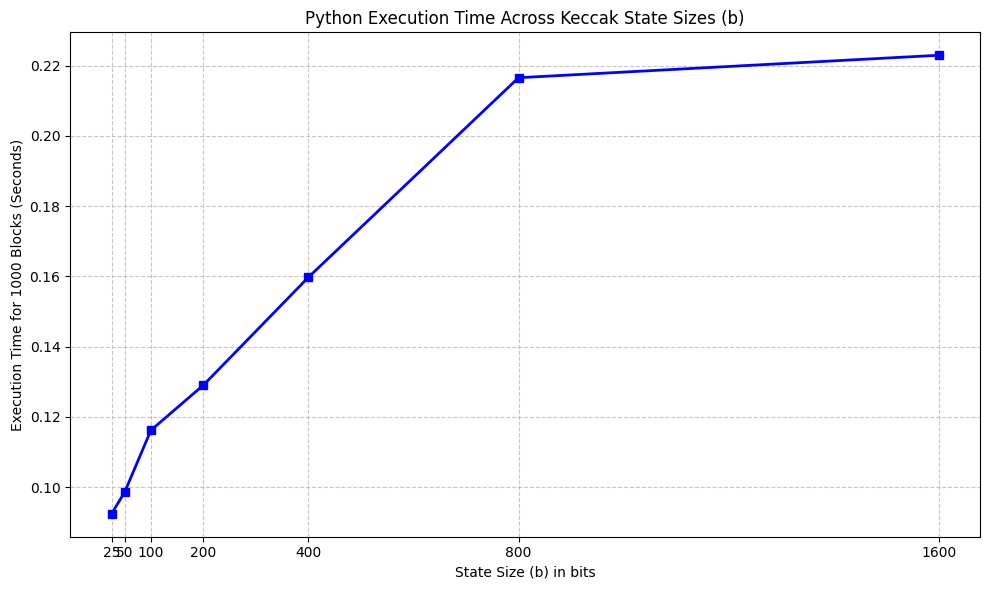

In [15]:
# pure_sha3_generalized.py
import time
import math
import matplotlib.pyplot as plt

# The full 64-bit constants
RC_1600 = [0x0000000000000001, 0x0000000000008082, 0x800000000000808A,
           0x8000000080008000, 0x000000000000808B, 0x0000000080000001,
           0x8000000080008081, 0x8000000000008009, 0x000000000000008A,
           0x0000000000000088, 0x0000000080008009, 0x000000008000000A,
           0x000000008000808B, 0x800000000000008B, 0x8000000000008089,
           0x8000000000008003, 0x8000000000008002, 0x8000000000000080,
           0x000000000000800A, 0x800000008000000A, 0x8000000080008081,
           0x8000000000008080, 0x0000000080000001, 0x8000000080008008]

ROT = [[0, 36, 3, 41, 18],
       [1, 44, 10, 45, 2],
       [62, 6, 43, 15, 61],
       [28, 55, 25, 21, 56],
       [27, 20, 39, 8, 14]]

def keccak_f_w(state, w):
    """A generalized Keccak permutation for any word size w."""
    # Create a mask to enforce the word size (e.g., w=8 makes an 8-bit mask)
    mask = (1 << w) - 1 
    
    # Calculate required rounds based on word size
    rounds = int(12 + 2 * math.log2(w))
    
    for i in range(rounds):
        # --- Theta ---
        C = [state[x][0] ^ state[x][1] ^ state[x][2] ^ state[x][3] ^ state[x][4] for x in range(5)]
        D = [0] * 5
        for x in range(5):
            rot_val = C[(x + 1) % 5]
            n = 1 % w
            if n != 0: # Only rotate if necessary
                rot_val = ((rot_val << n) | (rot_val >> (w - n))) & mask
            D[x] = C[(x - 1) % 5] ^ rot_val
            
        for x in range(5):
            for y in range(5):
                state[x][y] ^= D[x]
                
        # --- Rho and Pi ---
        B = [[0 for _ in range(5)] for _ in range(5)]
        for x in range(5):
            for y in range(5):
                rot_val = state[x][y]
                n = ROT[x][y] % w
                if n != 0:
                    rot_val = ((rot_val << n) | (rot_val >> (w - n))) & mask
                B[y][(2 * x + 3 * y) % 5] = rot_val
        state = B
        
        # --- Chi ---
        temp = [[state[x][y] for y in range(5)] for x in range(5)]
        for x in range(5):
            for y in range(5):
                # Using ^ mask instead of ~ to safely flip bits in Python
                flipped_neighbor = temp[(x + 1) % 5][y] ^ mask
                state[x][y] = temp[x][y] ^ (flipped_neighbor & temp[(x + 2) % 5][y])
                
        # --- Iota ---
        # Truncate the massive 64-bit constant down to our current word size
        state[0][0] ^= (RC_1600[i] & mask)
        
    return state

def profile_all_sizes(num_blocks=1000):
    w_values = [1, 2, 4, 8, 16, 32, 64]
    b_values = [25 * w for w in w_values]
    execution_times = []
    
    print(f"Profiling 1000 blocks across Keccak state sizes...")
    
    for w in w_values:
        state = [[0 for _ in range(5)] for _ in range(5)]
        
        start_time = time.time()
        for _ in range(num_blocks):
            state = keccak_f_w(state, w)
        end_time = time.time()
        
        time_taken = end_time - start_time
        execution_times.append(time_taken)
        
        # Print the data to the terminal as it runs
        rounds = int(12 + 2 * math.log2(w))
        print(f"b = {25*w:<4} (w={w:<2}) | Rounds: {rounds:<2} | Time: {time_taken:.4f}s")
        
    # Generate the graph
    plt.figure(figsize=(10, 6))
    plt.plot(b_values, execution_times, color='blue', marker='s', linewidth=2)
    plt.title('Python Execution Time Across Keccak State Sizes (b)')
    plt.xlabel('State Size (b) in bits')
    plt.ylabel('Execution Time for 1000 Blocks (Seconds)')
    plt.xticks(b_values)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    profile_all_sizes(1000)
    

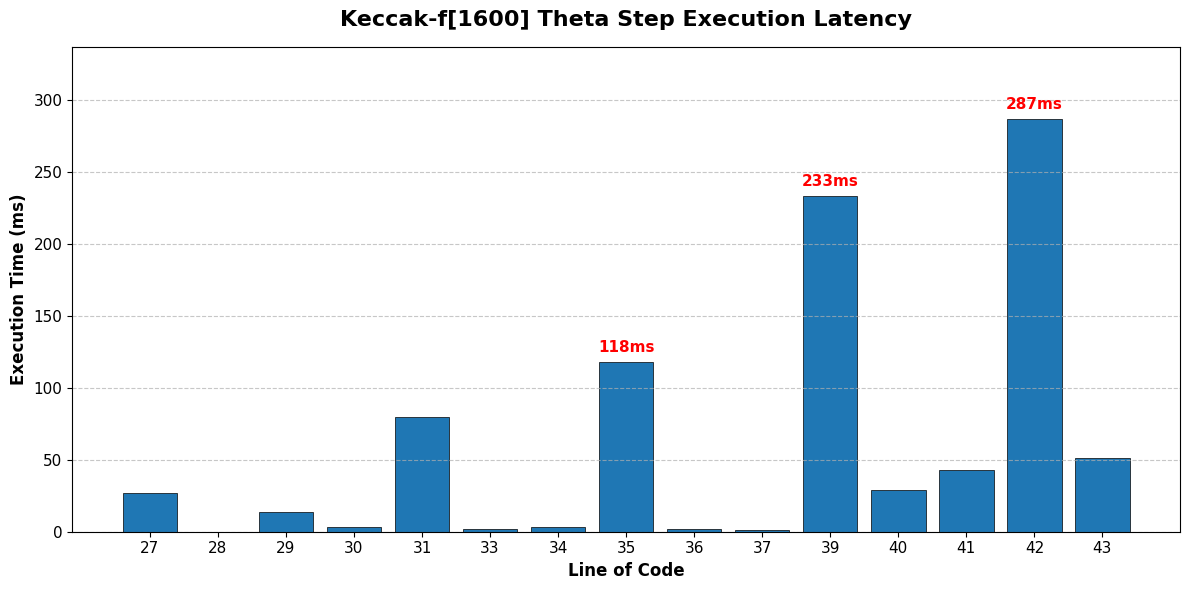

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Data extracted directly from the Apple Instruments trace (Theta step only)
lines = [
    27, 28, 29, 30, 31,  # Theta (C array)
    33, 34, 35, 36, 37,  # Theta (D array)
    39, 40, 41, 42, 43   # Theta (State XOR)
]

# Execution times in milliseconds (0 ms used for blank lines in the trace)
times_ms = [
    27, 0, 14, 3, 80,    # Theta (C array)
    2, 3, 118, 2, 1,     # Theta (D array)
    233, 29, 43, 287, 51 # Theta (State XOR)
]

# 2. Create the bar chart
# Made the figure slightly narrower (12, 6) since there are fewer bars to plot
plt.figure(figsize=(12, 6)) 
bars = plt.bar([str(l) for l in lines], times_ms, color='#1f77b4', edgecolor='black', linewidth=0.5)

# 3. Formatting and Labels
plt.title('Keccak-f[1600] Theta Step Execution Latency', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Line of Code', fontsize=12, fontweight='bold')
plt.ylabel('Execution Time (ms)', fontsize=12, fontweight='bold')
plt.ylim(0, max(times_ms) + 50)  # Add some headroom for the tallest bar

plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 4. Highlight the massive stalls with text annotations
for bar, time in zip(bars, times_ms):
    if time > 100:  # Only label the massive spikes > 100ms
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                 f'{time}ms', ha='center', va='bottom', fontsize=11, fontweight='bold', color='red')

# 5. Render the plot
plt.tight_layout()
plt.show()